# Pipeline de Treinamento — Previsão de `geek_rating` (BoardGameGeek)

Este notebook treina e compara 4 modelos para prever o **geek_rating** (Bayesian rating do BGG) a partir da base já tratada em `tratatamento_dados.ipynb`:

## 1. Imports

In [42]:
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform, loguniform
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold, ParameterSampler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler,  label_binarize
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve, log_loss
)

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42

In [2]:
# para regressão logística
cv_stratified = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# para demais modelos
cv_regression = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## 2. Carregamento dos dados

In [3]:
df = pd.read_csv("../data/bgg_dataset_tratado.csv")

print(f"Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"Valores nulos totais: {df.isna().sum().sum()}")
df.head()


Shape: 8,210 linhas x 159 colunas
Valores nulos totais: 0


,geek_rating,complexity,min_players,max_players,min_time,max_time,min_suggested_age,publisher_freq,min_time_was_missing,max_time_was_missing,min_suggested_age_was_missing,cat_Abstract Strategy,cat_Action,cat_Adventure,cat_Ancient,cat_Animals,cat_Bluffing,cat_Card Game,cat_Children's Game,cat_City Building,cat_Civilization,cat_Deduction,cat_Dexterity,cat_Dice,cat_Economic,...,desc_topic_28,desc_topic_29,desc_topic_30,desc_topic_31,desc_topic_32,desc_topic_33,desc_topic_34,desc_topic_35,desc_topic_36,desc_topic_37,desc_topic_38,desc_topic_39,desc_topic_40,desc_topic_41,desc_topic_42,desc_topic_43,desc_topic_44,desc_topic_45,desc_topic_46,desc_topic_47,desc_topic_48,desc_topic_49,desc_topic_50,desc_topic_51,desc_topic_52
0,8.394,3.86,2,4,60,120,14,0.001434,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,...,-0.058433,0.009345,0.016651,0.015986,0.025000,-0.030609,-0.081961,-0.016744,-0.009982,0.004833,-0.023359,-0.006700,0.052733,0.025746,0.019850,0.026079,0.043745,-0.015449,-0.025951,0.014756,-0.005542,0.034305,-0.014527,-0.028504,-0.014838
1,8.354,3.80,1,4,90,150,14,0.000717,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,...,-0.007228,-0.000323,-0.007158,-0.014286,-0.005762,-0.007796,-0.012167,0.005890,-0.002589,0.013608,-0.003286,0.005077,0.024767,0.003011,0.009170,-0.000891,0.028214,0.000953,-0.008084,-0.011957,-0.000410,0.005482,0.013064,0.002398,0.009475
2,8.345,2.83,2,4,60,60,13,0.003824,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0.030072,0.105894,0.147805,0.062949,0.016788,-0.083384,-0.083061,-0.055188,-0.073196,-0.014462,0.041995,0.020503,0.101092,0.024867,0.029581,0.060664,0.013352,0.010287,0.040223,-0.192117,0.088284,-0.062375,-0.111520,0.004890,-0.002578
3,8.296,3.92,1,4,60,120,14,0.000598,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,...,-0.004115,0.032672,-0.024888,-0.011800,0.042112,-0.024433,0.000060,-0.021509,0.040342,0.009034,-0.046759,-0.015859,-0.075984,0.045251,0.013637,-0.143884,-0.033575,0.044223,0.049792,0.067953,0.152963,-0.082917,0.082087,-0.026368,0.016273
4,8.244,3.52,1,6,60,120,13,0.000478,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0.002094,0.096413,0.017487,-0.033244,-0.074337,-0.002380,-0.047295,0.040982,-0.031296,-0.030977,0.010333,0.041498,0.029307,0.211799,0.005364,0.071105,-0.161384,-0.049646,0.021953,0.022739,-0.021775,-0.023202,0.085675,-0.043328,-0.076606


In [4]:
df["geek_rating"].describe()


count    8210.000000
mean        5.814454
std         0.480885
min         5.268000
25%         5.520000
50%         5.592000
75%         5.898000
max         8.394000
Name: geek_rating, dtype: float64

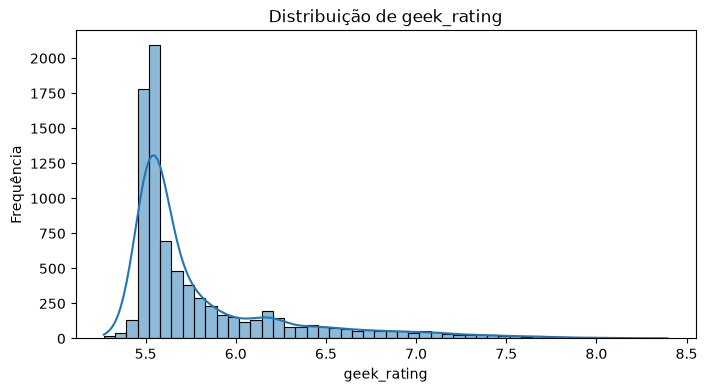

In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(df["geek_rating"], bins=50, kde=True)
plt.title("Distribuição de geek_rating")
plt.xlabel("geek_rating")
plt.ylabel("Frequência")
plt.show()


**Observação importante sobre a distribuição:** o `geek_rating` é fortemente assimétrico à direita. A maioria dos jogos se concentra perto do "piso" do Bayesian average do BGG (em torno de 5.5), e poucos jogos atingem ratings altos (>7.5). Isso afeta diretamente a versão de classificação (Regressão Logística): as faixas mais altas terão poucas amostras, o que é esperado e será discutido nos resultados.

## 3. Separação de features e targets

- `X`: todas as colunas exceto `geek_rating`.
- `y_reg`: o `geek_rating` contínuo (usado em Regressão Linear, Random Forest e Gradient Boosting).
- O target de classificação (`y_clf`) será derivado de `y_reg` *depois* do split treino/teste, para não vazar informação do teste na definição das faixas.

In [6]:
X = df.drop(columns=["geek_rating"])
y_reg = df["geek_rating"]

print(f"X: {X.shape}")
print(f"y_reg: {y_reg.shape}")


X: (8210, 158)
y_reg: (8210,)


## 4. Split treino/teste

Usamos `train_test_split` com 80% treino / 20% teste. Como as features já vêm padronizadas (RobustScaler) e codificadas do notebook de normalização, não há necessidade de pré-processamento adicional aqui.

In [7]:
# dividindo o conjunto em 70% treino, e 30% teste (temporário)
X_train, X_temp, y_train_reg, y_temp_reg = train_test_split(
    X,
    y_reg,
    test_size=0.30,
    random_state=RANDOM_STATE
)

# divide os 30% em 15% validação e 15% teste
X_val, X_test, y_val_reg, y_test_reg = train_test_split(
    X_temp,
    y_temp_reg,
    test_size=0.50,
    random_state=RANDOM_STATE
)

print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

# y_train_log = np.log(y_train_reg)
# y_val_log = np.log(y_val_reg)
# y_test_log = np.log(y_test_reg)

Treino: (5747, 158)
Validação: (1231, 158)
Teste: (1232, 158)


## 5. Discretização do target para a Regressão Logística


In [8]:
N_BINS = 3

# Cria 3 classes balanceadas por tercis — derivado APENAS do treino
y_train_clf, bin_edges = pd.qcut(
    y_train_reg,
    q=N_BINS,
    labels=False,
    retbins=True,
    duplicates='drop'
)

# Abre as extremidades para cobrir val/test sem erros de boundary
bin_edges[0] = -np.inf
bin_edges[-1] = np.inf

# Aplica exatamente os mesmos limites em val e teste
y_val_clf = pd.cut(
    y_val_reg,
    bins=bin_edges,
    labels=False,
    include_lowest=True
)

y_test_clf = pd.cut(
    y_test_reg,
    bins=bin_edges,
    labels=False,
    include_lowest=True
)

CLASS_NAMES = ["Baixo (0)", "Médio (1)", "Alto (2)"] 

print("Faixas criadas (geek_rating):")
for i in range(len(bin_edges) - 1):
    lo = f"{bin_edges[i]:.3f}" if not np.isinf(bin_edges[i]) else "-inf"
    hi = f"{bin_edges[i+1]:.3f}" if not np.isinf(bin_edges[i+1]) else "+inf"
    print(f"  Classe {i} ({CLASS_NAMES[i]}): {lo} até {hi}")

Faixas criadas (geek_rating):
  Classe 0 (Baixo (0)): -inf até 5.551
  Classe 1 (Médio (1)): 5.551 até 5.734
  Classe 2 (Alto (2)): 5.734 até +inf


             treino  validação  teste
geek_rating                          
0              1930        399    393
1              1903        419    399
2              1914        413    440



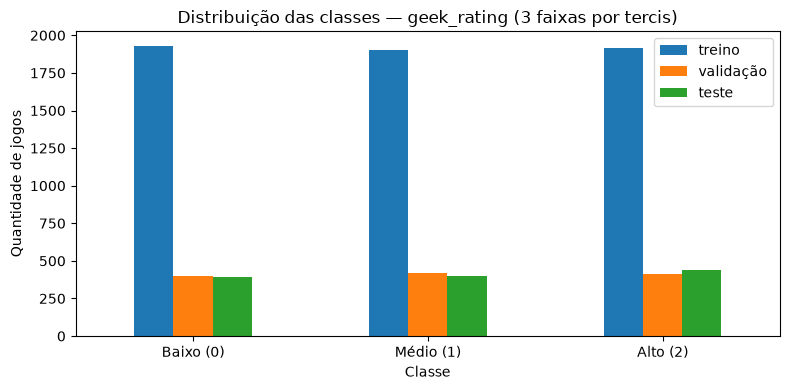

In [9]:
dist_treino = y_train_clf.value_counts().sort_index()
dist_val    = y_val_clf.value_counts().sort_index()
dist_teste  = y_test_clf.value_counts().sort_index()

dist_df = pd.DataFrame({
    "treino":    dist_treino,
    "validação": dist_val,
    "teste":     dist_teste,
}).fillna(0).astype(int)

print(dist_df)
print()

ax = dist_df.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_title("Distribuição das classes — geek_rating (3 faixas por tercis)")
ax.set_xlabel("Classe")
ax.set_ylabel("Quantidade de jogos")
ax.set_xticklabels(CLASS_NAMES)
plt.tight_layout()
plt.show()

## 6. Função auxiliar de avaliação (regressão)

Função utilitária para reportar RMSE, MAE e R² de forma consistente entre os 3 modelos de regressão.

In [10]:
def avaliar_regressao(nome_modelo, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5 # qual é a magnitude do erro, penalizando severamente os erros maiores
    mae = mean_absolute_error(y_test, y_pred) # em média, o quão distante a previsão está do valor real?
    r2 = r2_score(y_test, y_pred)

    print(f"--- {nome_modelo} ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")

    return {"modelo": nome_modelo, "RMSE": rmse, "MAE": mae, "R2": r2}


## 7. Modelo 1 — Regressão Linear Múltipla

In [11]:
# Criando o Pipeline
pipeline_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

t0 = time.time()

modelo_linear = pipeline_linear.fit(X_train, y_train_reg)

print(f"Tempo de treinamento: {time.time() - t0:.1f}s")

Tempo de treinamento: 0.1s


In [12]:
y_pred = modelo_linear.predict(X_test)

residuos = y_test_reg - y_pred

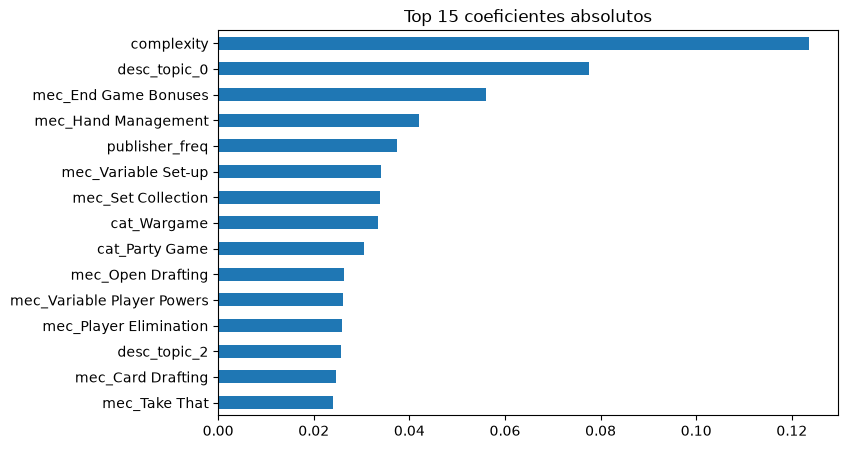

In [13]:
modelo_lr = modelo_linear.named_steps['model']

coef = pd.Series(
    modelo_lr.coef_,
    index=X_train.columns
)

top15 = (
    coef.abs()
        .sort_values(ascending=False)
        .head(15)
)

plt.figure(figsize=(8,5))

top15.sort_values().plot(kind="barh")

plt.title("Top 15 coeficientes absolutos")

plt.show()

In [14]:
resultado_linear = avaliar_regressao("Regressão Linear", modelo_linear, X_test, y_test_reg)


--- Regressão Linear ---
RMSE: 0.3923
MAE:  0.2792
R²:   0.3519


## 8. Modelo 2 — Random Forest Regressor

Random Forest costuma capturar bem relações não-lineares entre as features (ex: número de votos, complexidade, categorias) e o `geek_rating`.

In [15]:
pipeline_rf = Pipeline([
    ('model', RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1
    ))
])

best_score = -np.inf
best_params = None
best_model = None
candidatos_rf = []  # guarda (params, score) de toda combinação testada

# por que escol
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 
for params in ParameterSampler(
    param_dist_rf,
    n_iter=20,
    random_state=RANDOM_STATE
):

    model = RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params
    )

    model.fit(X_train, y_train_reg)

    pred_val = model.predict(X_val)

    score = r2_score(y_val_reg, pred_val)

    candidatos_rf.append({"params": params, "score_val": score})

    if score > best_score:
        best_score = score
        best_params = params
        best_model = model

print(best_score)
print(best_params)

0.40563059063526186
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30}


In [16]:
N_FINALISTAS = 3

# Ordena os candidatos testados pelo score na validação e pega os top N
finalistas_rf = sorted(candidatos_rf, key=lambda c: c["score_val"], reverse=True)[:N_FINALISTAS]

X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train_reg, y_val_reg])

print(f"Verificando estabilidade das {N_FINALISTAS} finalistas (Random Forest):\n")

resultados_estabilidade_rf = []

for finalista in finalistas_rf:
    params = finalista["params"]

    cv_scores = cross_val_score(
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **params),
        X_train_final, y_train_final,
        cv=cv_regression, scoring='r2', n_jobs=-1
    )

    resultados_estabilidade_rf.append({
        "params": params,
        "score_val": finalista["score_val"],
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std()
    })

    print(f"score_val={finalista['score_val']:.4f} | "
          f"CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | "
          f"{params}")

# Reordena pelas médias de CV — critério final mais robusto que score_val isolado
resultados_estabilidade_rf.sort(key=lambda r: r["cv_mean"], reverse=True)
melhor_estavel_rf = resultados_estabilidade_rf[0]

print()
if melhor_estavel_rf["params"] != best_params:
    print("A finalista mais estável na CV é DIFERENTE da escolhida só pelo hold-out.")
    print("Atualizando best_params para a versão mais estável.")
    best_params = melhor_estavel_rf["params"]
else:
    print("A escolha original (hold-out) se confirma como a mais estável na CV.")

Verificando estabilidade das 3 finalistas (Random Forest):

score_val=0.4056 | CV: 0.3861 ± 0.0165 | {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30}
score_val=0.4045 | CV: 0.3873 ± 0.0135 | {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}
score_val=0.4037 | CV: 0.3850 ± 0.0151 | {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}

A finalista mais estável na CV é DIFERENTE da escolhida só pelo hold-out.
Atualizando best_params para a versão mais estável.


In [17]:
final_model_rf = RandomForestRegressor(
    random_state=RANDOM_STATE,
    **best_params
)

final_model_rf.fit(
    X_train_final,
    y_train_final
)
resultado_rf = avaliar_regressao("Random Forest", final_model_rf, X_test, y_test_reg)

--- Random Forest ---
RMSE: 0.3807
MAE:  0.2588
R²:   0.3898


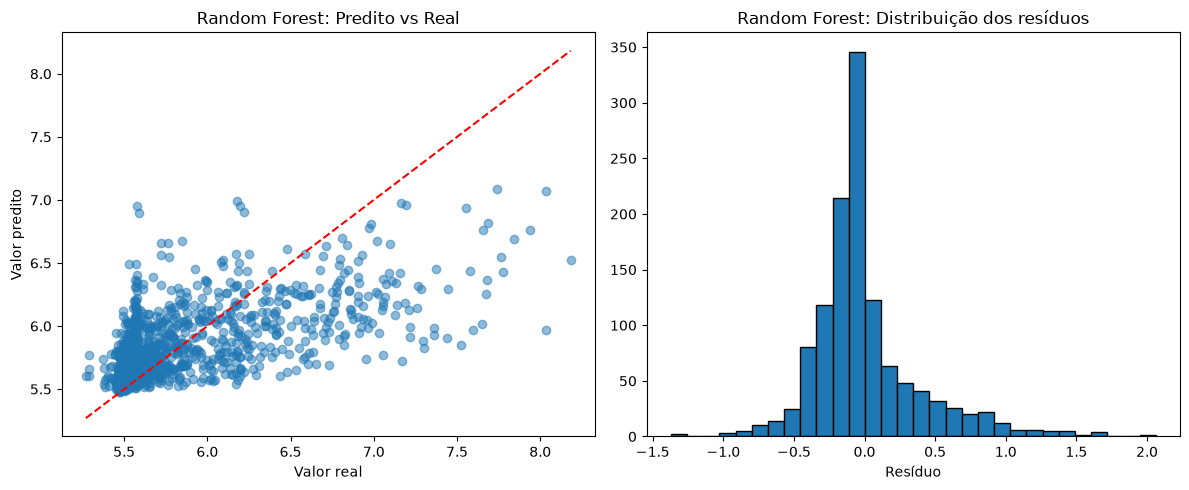

In [18]:
def plot_diagnostico_regressao(nome_modelo, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    residuos = y_test - y_pred

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(y_test, y_pred, alpha=0.5)
    axes[0].plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--'
    )
    axes[0].set_xlabel("Valor real")
    axes[0].set_ylabel("Valor predito")
    axes[0].set_title(f"{nome_modelo}: Predito vs Real")

    axes[1].hist(residuos, bins=30, edgecolor='black')
    axes[1].set_title(f"{nome_modelo}: Distribuição dos resíduos")
    axes[1].set_xlabel("Resíduo")

    plt.tight_layout()
    plt.show()

plot_diagnostico_regressao("Random Forest", final_model_rf, X_test, y_test_reg)

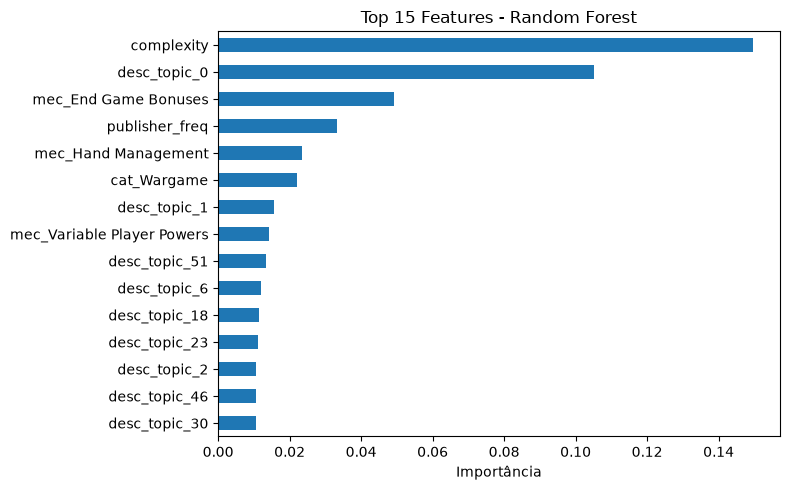

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

modelo_rf = final_model_rf

importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X_train.columns
)

top15 = importancias.sort_values(
    ascending=False
).head(15)

plt.figure(figsize=(8,5))
top15.sort_values().plot(kind="barh")
plt.title("Top 15 Features - Random Forest")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

## 9. Modelo 3 — Gradient Boosting Regressor

Gradient Boosting ajusta árvores sequencialmente, cada uma corrigindo os erros da anterior. Tende a ter desempenho competitivo, ao custo de mais tempo de treino.

In [20]:
pipeline_gb = Pipeline([
    ('model', GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ))
])

param_dist_gb = {
    "n_estimators": randint(50, 300),

    "learning_rate": uniform(loc=0.01, scale=0.15),

    "max_depth": randint(2, 6),

    "subsample": uniform(loc=0.7, scale=0.3),

    "min_samples_split": randint(2, 10),

    "min_samples_leaf": randint(1, 5)
}

t0 = time.time()

best_score = -np.inf
best_params = None
best_model = None
candidatos_gb = []

for params in ParameterSampler(
    param_dist_gb,
    n_iter=20,
    random_state=RANDOM_STATE
):

    model = GradientBoostingRegressor(
        random_state=RANDOM_STATE,
        **params
    )

    model.fit(X_train, y_train_reg)

    pred_val = model.predict(X_val)

    score = r2_score(y_val_reg, pred_val)

    candidatos_gb.append({"params": params, "score_val": score})

    if score > best_score:
        best_score = score
        best_params = params
        best_model = model

print(f"Tempo de treinamento: {time.time() - t0:.1f}s")
print(best_score)
print(best_params)

Tempo de treinamento: 219.3s
0.43441255609282425
{'learning_rate': np.float64(0.07841049763255538), 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 157, 'subsample': np.float64(0.8542703315240834)}


In [21]:
finalistas_gb = sorted(candidatos_gb, key=lambda c: c["score_val"], reverse=True)[:N_FINALISTAS]

X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train_reg, y_val_reg])

print(f"Verificando estabilidade das {N_FINALISTAS} finalistas (Gradient Boosting):\n")

resultados_estabilidade_gb = []

for finalista in finalistas_gb:
    params = finalista["params"]

    cv_scores = cross_val_score(
        GradientBoostingRegressor(random_state=RANDOM_STATE, **params),
        X_train_final, y_train_final,
        cv=cv_regression, scoring='r2', n_jobs=-1
    )

    resultados_estabilidade_gb.append({
        "params": params,
        "score_val": finalista["score_val"],
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std()
    })

    print(f"score_val={finalista['score_val']:.4f} | "
          f"CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | "
          f"{params}")

resultados_estabilidade_gb.sort(key=lambda r: r["cv_mean"], reverse=True)
melhor_estavel_gb = resultados_estabilidade_gb[0]

print()
if melhor_estavel_gb["params"] != best_params:
    print("A finalista mais estável na CV é DIFERENTE da escolhida só pelo hold-out.")
    print("Atualizando best_params para a versão mais estável.")
    best_params = melhor_estavel_gb["params"]
else:
    print("A escolha original (hold-out) se confirma como a mais estável na CV.")


Verificando estabilidade das 3 finalistas (Gradient Boosting):

score_val=0.4344 | CV: 0.4166 ± 0.0226 | {'learning_rate': np.float64(0.07841049763255538), 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 157, 'subsample': np.float64(0.8542703315240834)}
score_val=0.4258 | CV: 0.4199 ± 0.0214 | {'learning_rate': np.float64(0.033402796066365474), 'max_depth': 4, 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 252, 'subsample': np.float64(0.9598528437324805)}
score_val=0.4229 | CV: 0.4162 ± 0.0227 | {'learning_rate': np.float64(0.06927253540027216), 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 8, 'n_estimators': 97, 'subsample': np.float64(0.7979622306417505)}

A finalista mais estável na CV é DIFERENTE da escolhida só pelo hold-out.
Atualizando best_params para a versão mais estável.


In [22]:
final_model_gb = GradientBoostingRegressor(
    random_state=RANDOM_STATE,
    **best_params
)

final_model_gb.fit(
    X_train_final,
    y_train_final
)
resultado_gb = avaliar_regressao("Gradient Boosting", final_model_gb, X_test, y_test_reg)


--- Gradient Boosting ---
RMSE: 0.3757
MAE:  0.2557
R²:   0.4057


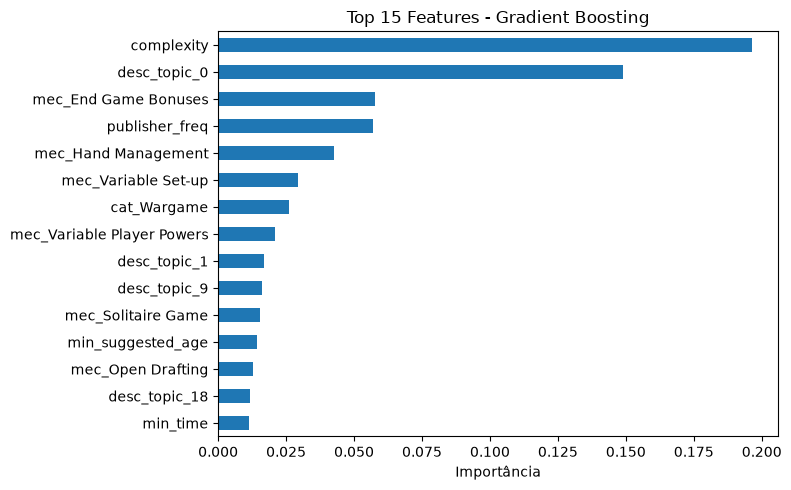

In [23]:
modelo_gb = final_model_gb

importancias = pd.Series(
    modelo_gb.feature_importances_,
    index=X_train.columns
)

top15 = importancias.sort_values(
    ascending=False
).head(15)

plt.figure(figsize=(8,5))
top15.sort_values().plot(kind="barh")
plt.title("Top 15 Features - Gradient Boosting")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

## 10. Modelo 4 — Regressão Logística (classificação em 10 faixas)

In [25]:
from scipy.stats import loguniform

param_dist_log = {
    "model__C":       loguniform(1e-3, 1e2),
    "model__penalty": [None, "l2", "l1"],
}

best_score  = -np.inf
best_params = None
best_model  = None
candidatos_log = []

for params in ParameterSampler(
    param_dist_log,
    n_iter=20,
    random_state=RANDOM_STATE
):
    # l1/none só funcionam com saga; l2 com qualquer solver
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=5000,
            solver="saga",
            class_weight="balanced",   # trata desbalanceamento residual
        ))
    ])

    # Se penalty=None, C não tem efeito — evitar erro
    if params["model__penalty"] is None:
        params = {"model__penalty": None, "model__C": 1.0}

    model.set_params(**params)
    model.fit(X_train, y_train_clf)

    pred_val = model.predict(X_val)
    score = f1_score(y_val_clf, pred_val, average="weighted")

    candidatos_log.append({"params": params, "score_val": score})

    if score > best_score:
        best_score  = score
        best_params = params
        best_model  = model

print(f"Melhor F1-weighted (val): {best_score:.4f}")
print(f"Melhores parâmetros:      {best_params}")

c:\Users\luiza\Documents\repo\trabalho_final_aprendizado_maq\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\luiza\Documents\repo\trabalho_final_aprendizado_maq\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty

Melhor F1-weighted (val): 0.5904
Melhores parâmetros:      {'model__C': np.float64(0.028585493941961918), 'model__penalty': 'l1'}


In [27]:
# Re-treina com treino + validação antes de avaliar no teste
X_train_final_clf = pd.concat([X_train, X_val])
y_train_final_clf = pd.concat([y_train_clf, y_val_clf])

modelo_logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=5000,
        solver="saga",
        class_weight="balanced",
    ))
])

modelo_logistic.set_params(**best_params)
modelo_logistic.fit(X_train_final_clf, y_train_final_clf)

print("Modelo final treinado com treino + validação.")

c:\Users\luiza\Documents\repo\trabalho_final_aprendizado_maq\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\luiza\Documents\repo\trabalho_final_aprendizado_maq\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Modelo final treinado com treino + validação.


In [28]:
y_pred_clf = modelo_logistic.predict(X_test)

acc                = accuracy_score(y_test_clf, y_pred_clf)
f1_weighted        = f1_score(y_test_clf,        y_pred_clf, average="weighted")
precision_weighted = precision_score(y_test_clf, y_pred_clf, average="weighted", zero_division=0)
recall_weighted    = recall_score(y_test_clf,    y_pred_clf, average="weighted", zero_division=0)

print("--- Regressão Logística (3 classes — tercis) ---")
print(f"Accuracy:              {acc:.4f}")
print(f"F1 (weighted):         {f1_weighted:.4f}")
print(f"Precision (weighted):  {precision_weighted:.4f}")
print(f"Recall (weighted):     {recall_weighted:.4f}")
print()
print(classification_report(
    y_test_clf,
    y_pred_clf,
    target_names=CLASS_NAMES,
    zero_division=0
))

--- Regressão Logística (3 classes — tercis) ---
Accuracy:              0.6047
F1 (weighted):         0.5998
Precision (weighted):  0.5983
Recall (weighted):     0.6047

              precision    recall  f1-score   support

   Baixo (0)       0.62      0.68      0.65       393
   Médio (1)       0.51      0.43      0.47       399
    Alto (2)       0.66      0.70      0.68       440

    accuracy                           0.60      1232
   macro avg       0.60      0.60      0.60      1232
weighted avg       0.60      0.60      0.60      1232



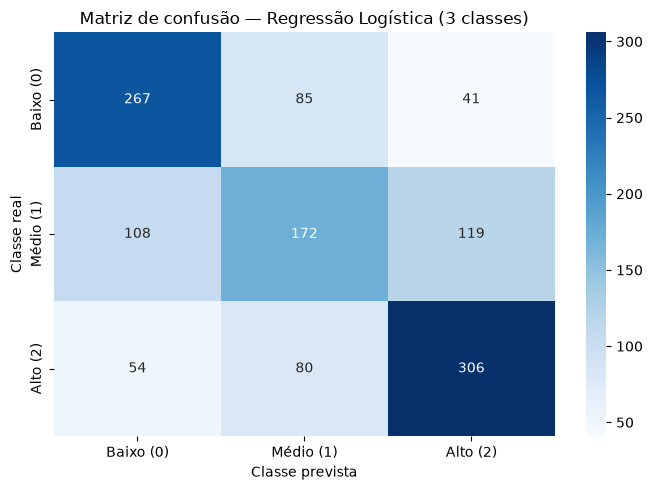

In [29]:
cm = confusion_matrix(y_test_clf, y_pred_clf, labels=range(N_BINS))

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title("Matriz de confusão — Regressão Logística (3 classes)")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.tight_layout()
plt.show()

In [30]:
y_prob = modelo_logistic.predict_proba(X_test)

In [31]:
roc_auc_weighted = roc_auc_score(
    y_test_clf,
    y_prob,
    multi_class="ovr",
    average="weighted"
)
print(f"ROC-AUC (OvR, weighted): {roc_auc_weighted:.4f}")

ROC-AUC (OvR, weighted): 0.7841


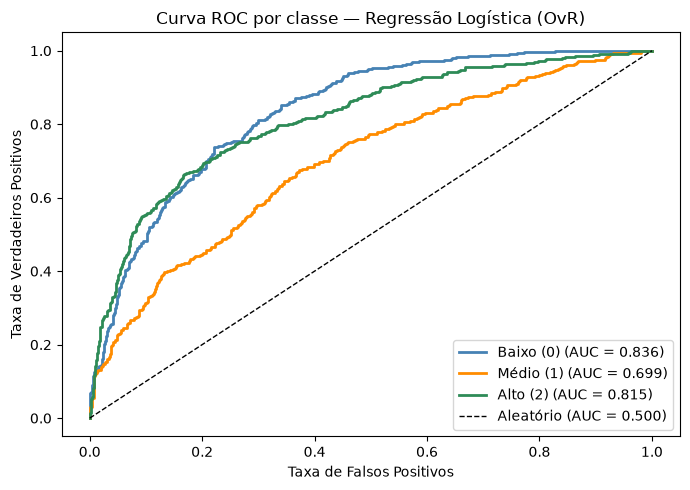

In [40]:
y_test_bin = label_binarize(y_test_clf, classes=range(N_BINS))

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["steelblue", "darkorange", "seagreen"]

for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{name} (AUC = {auc_i:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Aleatório (AUC = 0.500)")
ax.set_xlabel("Taxa de Falsos Positivos")
ax.set_ylabel("Taxa de Verdadeiros Positivos")
ax.set_title("Curva ROC por classe — Regressão Logística (OvR)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
loss = log_loss(y_test_clf, y_prob)
print(f"Log-Loss (Cross-Entropy): {loss:.4f}")
print()
print("Referência:")
print(f"  Classificador aleatório (3 classes): {-np.log(1/N_BINS):.4f}")
print(f"  Seu modelo:                           {loss:.4f}  ",
      "✓ melhor que aleatório" if loss < -np.log(1/N_BINS) else "✗ pior que aleatório")

Log-Loss (Cross-Entropy): 0.8554

Referência:
  Classificador aleatório (3 classes): 1.0986
  Classificador perfeito:               0.0000
  Seu modelo:                           0.8554   ✓ melhor que aleatório


In [34]:
# Cross-validation estratificada para avaliar estabilidade
X_all_clf = pd.concat([X_train, X_val, X_test])
y_all_clf  = pd.concat([y_train_clf, y_val_clf, y_test_clf])

cv_scores = cross_val_score(
    modelo_logistic,
    X_all_clf,
    y_all_clf,
    cv=cv_stratified,
    scoring="f1_weighted",
    n_jobs=-1,
)

print(f"CV F1-weighted (5 folds): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Scores por fold:          {[round(s,4) for s in cv_scores]}")


CV F1-weighted (5 folds): 0.6002 ± 0.0100
Scores por fold:          [np.float64(0.5953), np.float64(0.6036), np.float64(0.5971), np.float64(0.5875), np.float64(0.6172)]


In [35]:
resultado_logistic = {
    "modelo":               "Regressão Logística (3 classes — tercis)",
    "Accuracy":             acc,
    "F1_weighted":          f1_weighted,
    "Precision_weighted":   precision_weighted,
    "Recall_weighted":      recall_weighted,
}

## Comparação Final

In [37]:
### 11.1 Tabela comparativa
comparacao = pd.DataFrame([
    {k: v for k, v in resultado_linear.items() if k != "y_pred"},
    {k: v for k, v in resultado_rf.items() if k != "y_pred"},
    {k: v for k, v in resultado_gb.items() if k != "y_pred"},
]).set_index("modelo")

comparacao = comparacao.rename(columns={
    "Loss_MSE": "Loss (MSE)",
    "RMSE": "RMSE",
    "MAE": "MAE",
    "MAPE": "MAPE (%)",
    "R2": "R²",
    "tempo_treino_s": "Tempo de treino (s)",
})

comparacao

,RMSE,MAE,R²
modelo,,,
Regressão Linear,0.392311,0.279210,0.351930
Random Forest,0.380663,0.258781,0.389841
Gradient Boosting,0.375678,0.255723,0.405718


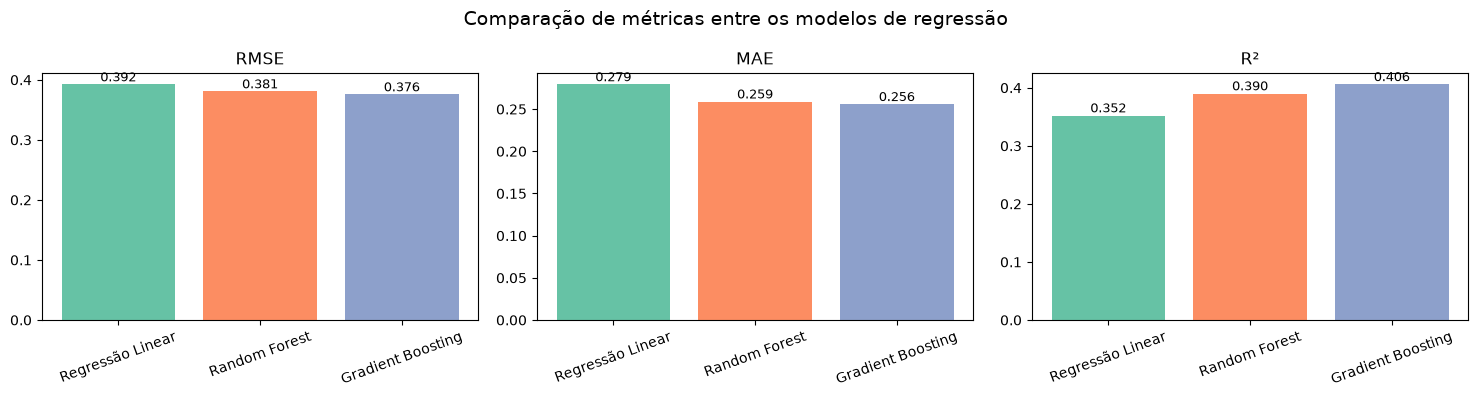

In [ ]:
metricas_plot = comparacao.columns

n_metricas = len(metricas_plot)
n_cols = 3
n_rows = math.ceil(n_metricas / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

cores = sns.color_palette("Set2", n_colors=len(comparacao))

for ax, metrica in zip(axes, metricas_plot):
    valores = comparacao[metrica]

    barras = ax.bar(
        valores.index,
        valores.values,
        color=cores
    )

    ax.set_title(metrica)
    ax.tick_params(axis="x", rotation=20)

    # posição do texto acima das barras
    offset = 0.01 * (valores.max() - valores.min())

    for barra, valor in zip(barras, valores.values):
        ax.text(
            barra.get_x() + barra.get_width()/2,
            barra.get_height() + offset,
            f"{valor:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

# remove eixos vazios
for ax in axes[n_metricas:]:
    fig.delaxes(ax)

plt.suptitle(
    "Comparação de métricas entre os modelos de regressão",
    fontsize=14
)

plt.tight_layout()
plt.show()

KeyError: 'y_pred'

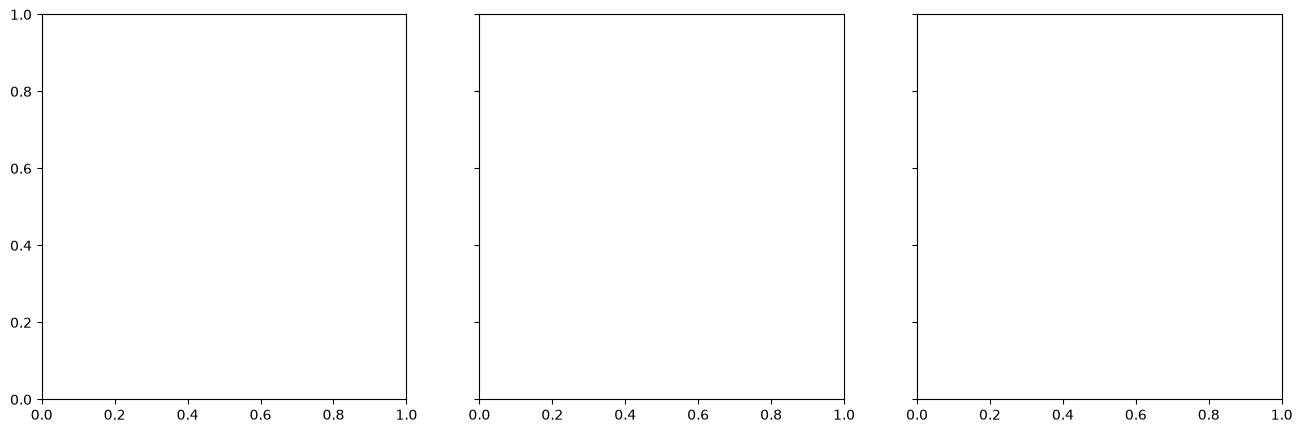

In [39]:
### 11.3 Predito vs Real — os 3 modelos lado a lado

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

modelos_preditos = [
    ("Regressão Linear", resultado_linear["y_pred"]),
    ("Random Forest", resultado_rf["y_pred"]),
    ("Gradient Boosting", resultado_gb["y_pred"]),
]

for ax, (nome, y_pred) in zip(axes, modelos_preditos):
    ax.scatter(y_test_reg, y_pred, alpha=0.4, s=15)
    ax.plot(
        [y_test_reg.min(), y_test_reg.max()],
        [y_test_reg.min(), y_test_reg.max()],
        'r--'
    )
    ax.set_title(nome)
    ax.set_xlabel("Valor real")

axes[0].set_ylabel("Valor predito")
plt.suptitle("Predito vs Real — comparação entre modelos")
plt.tight_layout()
plt.show()

In [ ]:
### 11.4 Resíduos — comparação das distribuições

plt.figure(figsize=(9, 5))

for nome, y_pred in modelos_preditos:
    residuos = y_test_reg - y_pred
    sns.kdeplot(residuos, label=nome, fill=True, alpha=0.2)

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title("Distribuição dos resíduos — comparação entre modelos")
plt.xlabel("Resíduo (real - predito)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
### 11.5 Conclusão automática

melhor_rmse = comparacao["RMSE"].idxmin()
melhor_mae = comparacao["MAE"].idxmin()
melhor_mape = comparacao["MAPE (%)"].idxmin()
melhor_r2 = comparacao["R²"].idxmax()
mais_rapido = comparacao["Tempo de treino (s)"].idxmin()

print("Resumo comparativo:")
print(f"- Menor Loss/RMSE:        {melhor_rmse}")
print(f"- Menor MAE:              {melhor_mae}")
print(f"- Menor MAPE:             {melhor_mape}")
print(f"- Maior R² (melhor ajuste geral): {melhor_r2}")
print(f"- Treino mais rápido:     {mais_rapido}")

print()
print(f">>> Modelo recomendado (maior R²): {melhor_r2}")